customer segmentation
- unsupervised
- clustering


Only the data points for the subscribers (data entries where y = 'yes') were used.

In [ ]:
import random

seed = 2694 #random.randint(1000, 9999)

# Data Import

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/My Drive/Apziva/Project 2 - Term Deposit/term-deposit-marketing-2020.csv'

Mounted at /content/drive


In [ ]:
import duckdb

# Connect to an in-memory DuckDB database
con = duckdb.connect(database=':memory:', read_only=False)

# Load the CSV file into a DuckDB table and filter for subscribers
subscribers_df = con.execute(f"SELECT * FROM '{data_path}' WHERE y = 'yes'").fetchdf()

# Display the head of the filtered DataFrame
print("Subscribers DataFrame head:")
print(subscribers_df.head())

# Display information about the filtered DataFrame
print("\nSubscribers DataFrame info:")
subscribers_df.info()

Subscribers DataFrame head:
   age         job  marital  education  default  balance  housing   loan  \
0   59       admin  married  secondary    False     2343     True  False   
1   56       admin  married  secondary    False       45    False  False   
2   41  technician  married  secondary    False     1270     True  False   
3   55    services  married  secondary    False     2476     True  False   
4   54       admin  married   tertiary    False      184    False  False   

   contact  day month  duration  campaign     y  
0  unknown    5   may      1042         1  True  
1  unknown    5   may      1467         1  True  
2  unknown    5   may      1389         1  True  
3  unknown    5   may       579         1  True  
4  unknown    5   may       673         2  True  

Subscribers DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2896 entries, 0 to 2895
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 

# Customer Segmentation

## Data Processing

Apply a log transformation (np.log1p) to the 'balance', 'duration', and 'campaign' columns mitigate their skewness

In [ ]:
import pandas as pd

# Drop the target column 'y' as it's not needed for unsupervised clustering
subscribers_features_df = subscribers_df.drop('y', axis=1)

In [ ]:
import numpy as np

# Create a copy of the subscribers_features_df
subscribers_features_log_transformed_df = subscribers_features_df.copy()

# Apply log transformation (np.log1p) to the specified columns
skewed_features = ['balance', 'duration', 'campaign']
for feature in skewed_features:
    subscribers_features_log_transformed_df[feature] = np.log1p(subscribers_features_log_transformed_df[feature])

print("Subscribers Features Log Transformed DataFrame head:")
print(subscribers_features_log_transformed_df.head())

print("\nSubscribers Features Log Transformed DataFrame info:")
subscribers_features_log_transformed_df.info()

Subscribers Features Log Transformed DataFrame head:
   age         job  marital  education  default   balance  housing   loan  \
0   59       admin  married  secondary    False  7.759614     True  False   
1   56       admin  married  secondary    False  3.828641    False  False   
2   41  technician  married  secondary    False  7.147559     True  False   
3   55    services  married  secondary    False  7.814803     True  False   
4   54       admin  married   tertiary    False  5.220356    False  False   

   contact  day month  duration  campaign  
0  unknown    5   may  6.949856  0.693147  
1  unknown    5   may  7.291656  0.693147  
2  unknown    5   may  7.237059  0.693147  
3  unknown    5   may  6.363028  0.693147  
4  unknown    5   may  6.513230  1.098612  

Subscribers Features Log Transformed DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2896 entries, 0 to 2895
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     ---

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [ ]:
import pandas as pd
import numpy as np # Ensure numpy is imported for np.inf
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify numerical and categorical columns from the log-transformed features DataFrame
new_numerical_cols = subscribers_features_log_transformed_df.select_dtypes(include=['int64', 'float64']).columns
new_categorical_cols = subscribers_features_log_transformed_df.select_dtypes(include=['object', 'bool']).columns

# Identify numerical columns with zero standard deviation to exclude them from scaling
non_constant_numerical_cols = []
constant_numerical_cols = []

for col in new_numerical_cols:
    # Check for infinite values first, as they are not caught by .std() == 0 and cause StandardScaler to fail
    if (subscribers_features_log_transformed_df[col] == np.inf).any() or (subscribers_features_log_transformed_df[col] == -np.inf).any():
        print(f"Warning: Numerical column '{col}' contains infinite values. Replacing with NaN and then imputing with median.")
        subscribers_features_log_transformed_df[col].replace([np.inf, -np.inf], np.nan, inplace=True)

    # After handling infinities, check for NaNs that might have been introduced or were already present
    if subscribers_features_log_transformed_df[col].isnull().any():
        median_val = subscribers_features_log_transformed_df[col].median()
        subscribers_features_log_transformed_df[col].fillna(median_val, inplace=True)
        print(f"Warning: Numerical column '{col}' contained NaN values. Filled with median: {median_val}")

    if subscribers_features_log_transformed_df[col].std() == 0:
        constant_numerical_cols.append(col)
    else:
        non_constant_numerical_cols.append(col)

print(f"Numerical columns with zero standard deviation (will be dropped for scaling): {constant_numerical_cols}")

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer_new = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer_new = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a column transformer to apply different transformations to different columns
preprocessor_new = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_new, non_constant_numerical_cols),
        ('cat', categorical_transformer_new, new_categorical_cols)
    ])

# Apply preprocessing to the log-transformed features
subscribers_log_preprocessed = preprocessor_new.fit_transform(subscribers_features_log_transformed_df)

# Get feature names after one-hot encoding for the new preprocessor
onehot_feature_names_new = preprocessor_new.named_transformers_['cat']['onehot'].get_feature_names_out(new_categorical_cols)
all_feature_names_new = list(non_constant_numerical_cols) + list(onehot_feature_names_new)

# Convert the preprocessed data to a dense array before converting to a DataFrame
subscribers_log_preprocessed_df = pd.DataFrame(subscribers_log_preprocessed.toarray(), columns=all_feature_names_new, index=subscribers_features_log_transformed_df.index)

print("Preprocessed Log-Transformed Subscribers DataFrame head:")
print(subscribers_log_preprocessed_df.head())

print("\nPreprocessed Log-Transformed Subscribers DataFrame shape:")
print(subscribers_log_preprocessed_df.shape)

Numerical columns with zero standard deviation (will be dropped for scaling): []
Preprocessed Log-Transformed Subscribers DataFrame head:
        age   balance       day  duration  campaign  job_admin  \
0  1.741354  0.737311 -1.265409  0.892061 -0.874911        1.0   
1  1.468629 -1.069129 -1.265409  1.366010 -0.874911        1.0   
2  0.105003  0.456047 -1.265409  1.290304 -0.874911        0.0   
3  1.377720  0.762672 -1.265409  0.078348 -0.874911        0.0   
4  1.286812 -0.429580 -1.265409  0.286623  0.002145        1.0   

   job_blue-collar  job_entrepreneur  job_housemaid  job_management  ...  \
0              0.0               0.0            0.0             0.0  ...   
1              0.0               0.0            0.0             0.0  ...   
2              0.0               0.0            0.0             0.0  ...   
3              0.0               0.0            0.0             0.0  ...   
4              0.0               0.0            0.0             0.0  ...   

   month

/tmp/ipython-input-1923737977.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  subscribers_features_log_transformed_df[col].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-1923737977.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doin

## Clustering using the K-Means Algorithm

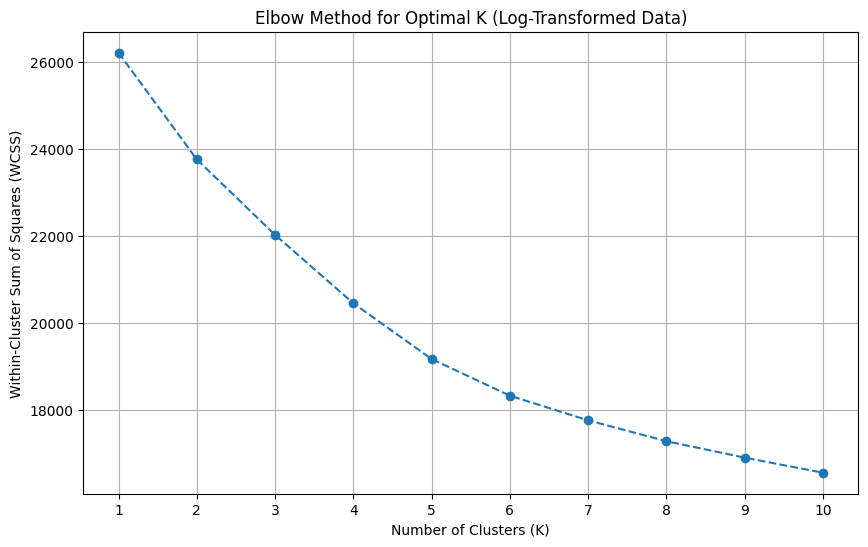

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Determine the optimal number of clusters using the Elbow method on the new preprocessed data
wcss_new = []
for i in range(1, 11):
    kmeans_new = KMeans(n_clusters=i, init='k-means++', random_state=seed, n_init=10)
    kmeans_new.fit(subscribers_log_preprocessed_df)
    wcss_new.append(kmeans_new.inertia_)

# Plot the Elbow method
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss_new, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K (Log-Transformed Data)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Based on the Elbow plot for log-transformed data, choose the optimal number of clusters.
optimal_k_new = 5 # Adjust this value based on your interpretation of the Elbow plot.

# Apply K-Means clustering to the log-transformed and preprocessed data
kmeans_model_new = KMeans(n_clusters=optimal_k_new, init='k-means++', random_state=seed, n_init=10)
cluster_labels_new = kmeans_model_new.fit_predict(subscribers_log_preprocessed_df)

# Add new cluster labels to both the original log-transformed DataFrame and the preprocessed one
subscribers_features_log_transformed_df['cluster'] = cluster_labels_new
subscribers_log_preprocessed_df['cluster'] = cluster_labels_new

print(f"K-Means clustering applied with {optimal_k_new} clusters to log-transformed data.")

K-Means clustering applied with 5 clusters to log-transformed data.


### Inverse scale the Numeric Features

In [ ]:
import pandas as pd
import numpy as np

# 1. Extract the numerical features from the subscribers_log_preprocessed_df (excluding 'cluster')
# These are already scaled, and some are log-transformed.
scaled_log_numerical_features = subscribers_log_preprocessed_df[new_numerical_cols]

# 2. Access the StandardScaler from the preprocessor_new pipeline
scaler_new = preprocessor_new.named_transformers_['num']['scaler']

# 3. Apply the inverse_transform method of the StandardScaler to get the log-transformed values
inverse_scaled_log_numerical_array = scaler_new.inverse_transform(scaled_log_numerical_features)

# 4. Create a temporary DataFrame with these inverse-scaled log-transformed numerical features
inverse_scaled_log_numerical_df = pd.DataFrame(inverse_scaled_log_numerical_array, columns=new_numerical_cols, index=subscribers_log_preprocessed_df.index)

# 5. Apply the inverse of log1p (expm1) to 'balance', 'duration', and 'campaign' columns
reverted_numerical_df = inverse_scaled_log_numerical_df.copy()

skewed_features = ['balance', 'duration', 'campaign']
for feature in skewed_features:
    reverted_numerical_df[feature] = np.expm1(reverted_numerical_df[feature])

# Adjust 'balance' back by adding the min_val_balance if it was shifted before log1p
min_val_balance = subscribers_features_df['balance'].min()
if min_val_balance < 0:
    reverted_numerical_df['balance'] = reverted_numerical_df['balance'] + min_val_balance

# Ensure 'balance', 'duration', 'campaign' are non-negative after inverse transformation
for feature in skewed_features:
    reverted_numerical_df[feature] = reverted_numerical_df[feature].apply(lambda x: max(0, x))

# Identify categorical columns that were one-hot encoded from the preprocessed df (excluding 'cluster')
# 'new_categorical_cols' contains the original categorical column names.
# 'onehot_feature_names_new' contains the names of the one-hot encoded columns.
# We need the actual one-hot encoded columns from subscribers_log_preprocessed_df
onehot_categorical_data_from_preprocessed = subscribers_log_preprocessed_df[onehot_feature_names_new]

# Combine inverse-scaled numerical features, one-hot encoded categorical features, and the cluster labels
reconstructed_log_transformed_df = pd.concat([
    reverted_numerical_df,
    onehot_categorical_data_from_preprocessed,
    subscribers_log_preprocessed_df['cluster']
], axis=1)

print("Head of the Reconstructed DataFrame (with original scale numerical features):")
print(reconstructed_log_transformed_df.head())
print("\nShape of the Reconstructed DataFrame:")
print(reconstructed_log_transformed_df.shape)

Head of the Reconstructed DataFrame (with original scale numerical features):
    age  balance  day  duration  campaign  job_admin  job_blue-collar  \
0  59.0      0.0  5.0    1042.0       1.0        1.0              0.0   
1  56.0      0.0  5.0    1467.0       1.0        1.0              0.0   
2  41.0      0.0  5.0    1389.0       1.0        0.0              0.0   
3  55.0      0.0  5.0     579.0       1.0        0.0              0.0   
4  54.0      0.0  5.0     673.0       2.0        1.0              0.0   

   job_entrepreneur  job_housemaid  job_management  ...  month_dec  month_feb  \
0               0.0            0.0             0.0  ...        0.0        0.0   
1               0.0            0.0             0.0  ...        0.0        0.0   
2               0.0            0.0             0.0  ...        0.0        0.0   
3               0.0            0.0             0.0  ...        0.0        0.0   
4               0.0            0.0             0.0  ...        0.0        0.0 

### Clustering Results

Challenges in plotting high dimensional data

Some clusters could have sub-clusters inside.

In [ ]:
print("Mean values of inverse-scaled numerical features per new cluster:")
print(reconstructed_log_transformed_df.groupby('cluster')[new_numerical_cols].mean())

Mean values of inverse-scaled numerical features per new cluster:
               age     balance        day    duration  campaign
cluster                                                        
0        39.093284    0.000000  15.820896  682.149254  2.570896
1        33.152397  751.227740  18.683219  285.270548  1.563356
2        35.143275  379.877193  14.118908  888.055556  1.686160
3        55.877432  777.945525  13.645914  562.221790  1.671206
4        41.220238  631.581349  18.222222  849.815476  5.557540


/tmp/ipython-input-3765580095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_numerical_features.index, y=col, data=mean_numerical_features, palette='viridis')


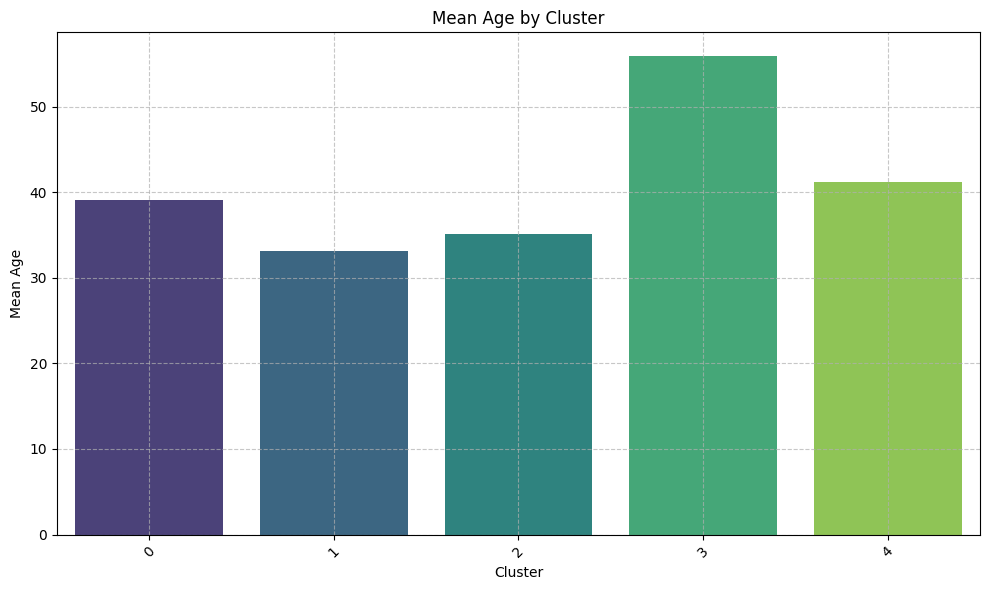

/tmp/ipython-input-3765580095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_numerical_features.index, y=col, data=mean_numerical_features, palette='viridis')


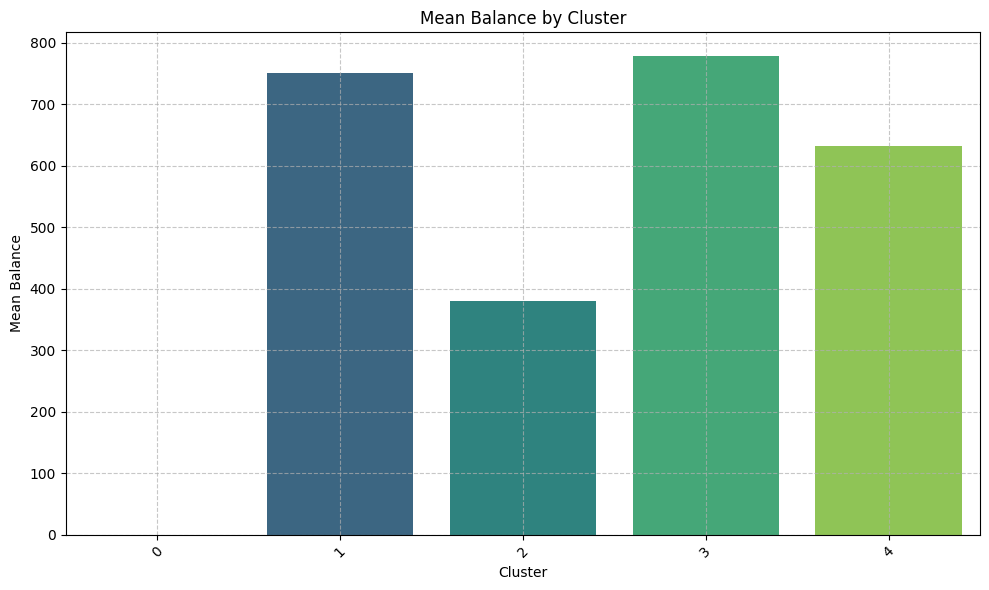

/tmp/ipython-input-3765580095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_numerical_features.index, y=col, data=mean_numerical_features, palette='viridis')


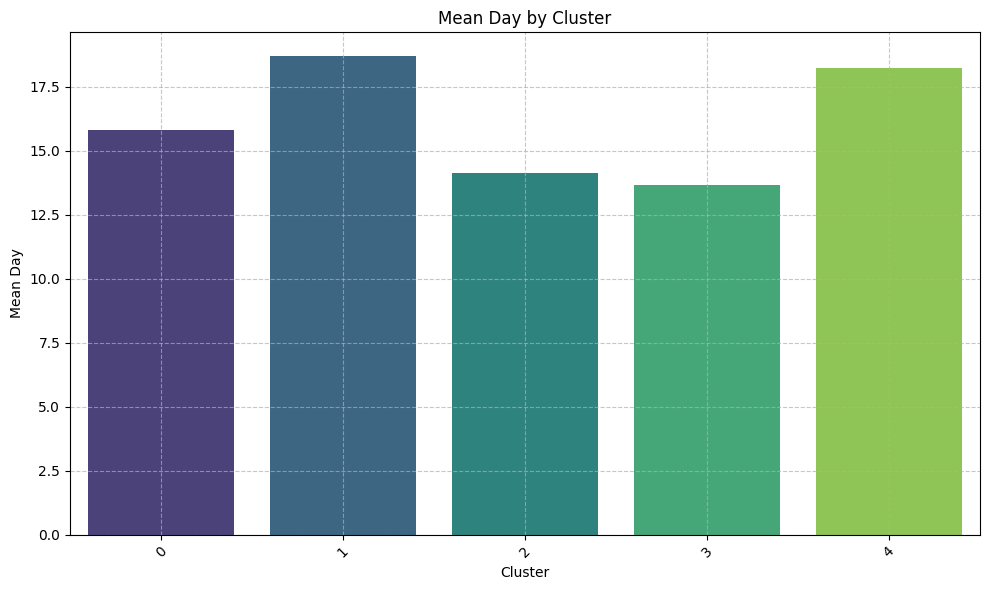

/tmp/ipython-input-3765580095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_numerical_features.index, y=col, data=mean_numerical_features, palette='viridis')


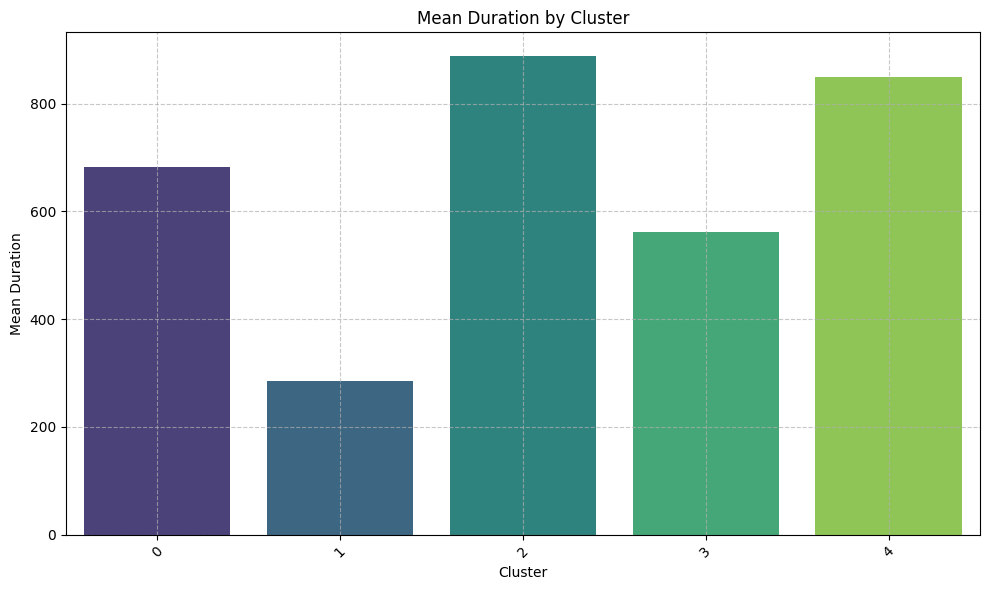

/tmp/ipython-input-3765580095.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_numerical_features.index, y=col, data=mean_numerical_features, palette='viridis')


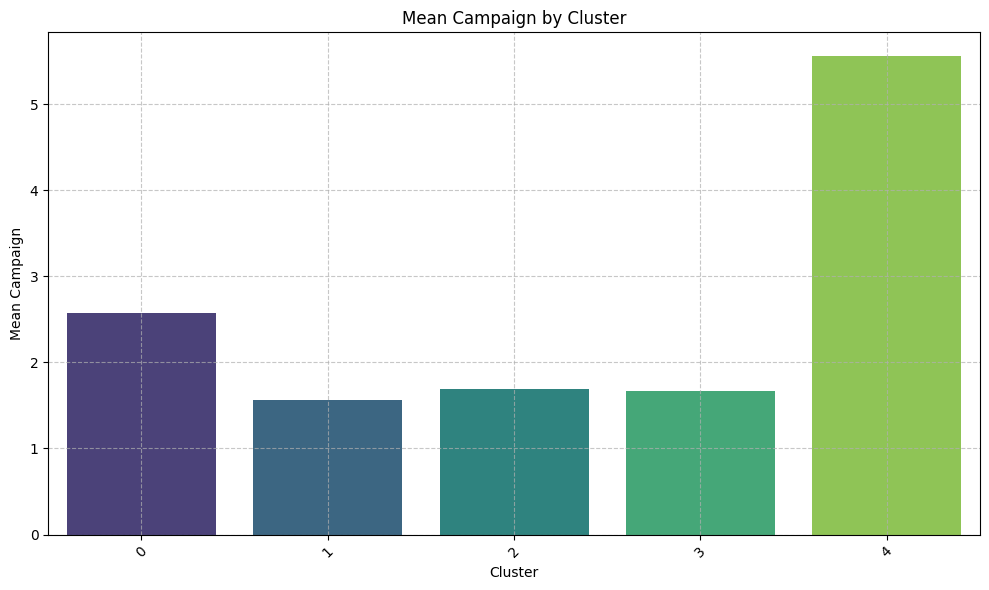

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate mean values of inverse-scaled numerical features per new cluster
mean_numerical_features = reconstructed_log_transformed_df.groupby('cluster')[new_numerical_cols].mean()

# Plot mean numerical features per cluster, one plot at a time
for col in new_numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=mean_numerical_features.index, y=col, data=mean_numerical_features, palette='viridis')
    plt.title(f'Mean {col.capitalize()} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(f'Mean {col.capitalize()}')
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [ ]:
print("\nMode of original categorical features per new cluster:")
for col in new_categorical_cols:
    print(f"\nFeature: {col}")
    print(subscribers_features_log_transformed_df.groupby('cluster')[col].apply(lambda x: x.mode()[0]))


Mode of original categorical features per new cluster:

Feature: job
cluster
0     management
1     management
2    blue-collar
3        retired
4     management
Name: job, dtype: object

Feature: marital
cluster
0    married
1     single
2     single
3    married
4    married
Name: marital, dtype: object

Feature: education
cluster
0    secondary
1     tertiary
2    secondary
3    secondary
4    secondary
Name: education, dtype: object

Feature: default
cluster
0    False
1    False
2    False
3    False
4    False
Name: default, dtype: bool

Feature: housing
cluster
0    False
1    False
2     True
3    False
4    False
Name: housing, dtype: bool

Feature: loan
cluster
0    False
1    False
2    False
3    False
4    False
Name: loan, dtype: bool

Feature: contact
cluster
0    cellular
1    cellular
2    cellular
3    cellular
4    cellular
Name: contact, dtype: object

Feature: month
cluster
0    may
1    apr
2    may
3    apr
4    jul
Name: month, dtype: object


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


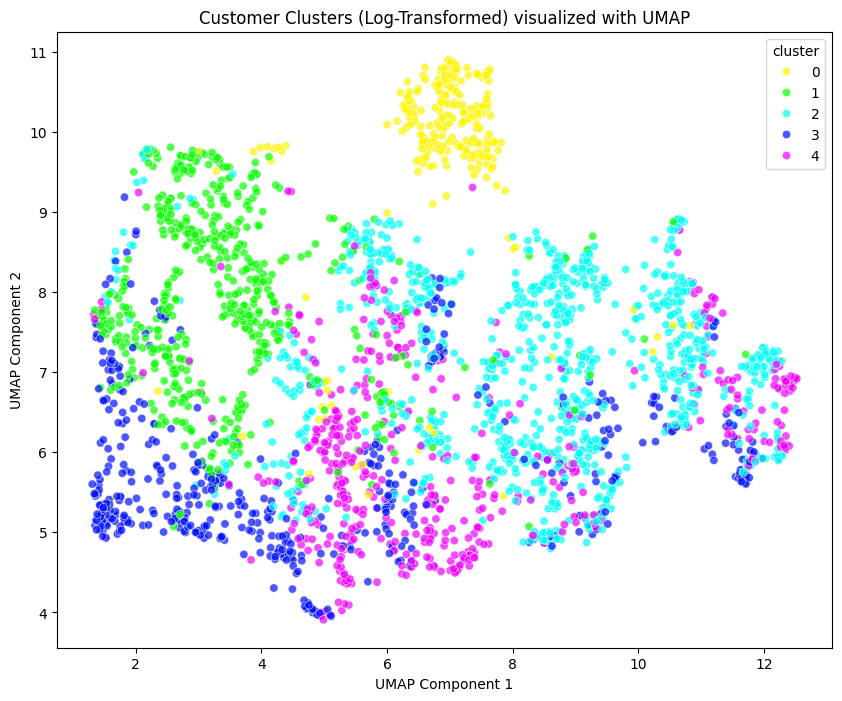

In [ ]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for UMAP (exclude the 'cluster' column as it's the target for visualization)
features_for_umap_new = subscribers_log_preprocessed_df.drop('cluster', axis=1)

# Apply UMAP
# Ensure n_components and random_state are consistent if desired
reducer_new = umap.UMAP(n_components=2, random_state=seed)
umap_results_new = reducer_new.fit_transform(features_for_umap_new)

# Create a DataFrame for the UMAP results
umap_df_new = pd.DataFrame(data=umap_results_new, columns=['umap_1', 'umap_2'])
umap_df_new['cluster'] = subscribers_log_preprocessed_df['cluster']

# Plot the UMAP results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='umap_1',
    y='umap_2',
    hue='cluster',
    palette=sns.color_palette('hsv', optimal_k_new),
    data=umap_df_new,
    legend='full',
    alpha=0.7
)
plt.title('Customer Clusters (Log-Transformed) visualized with UMAP')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(False)
plt.show()

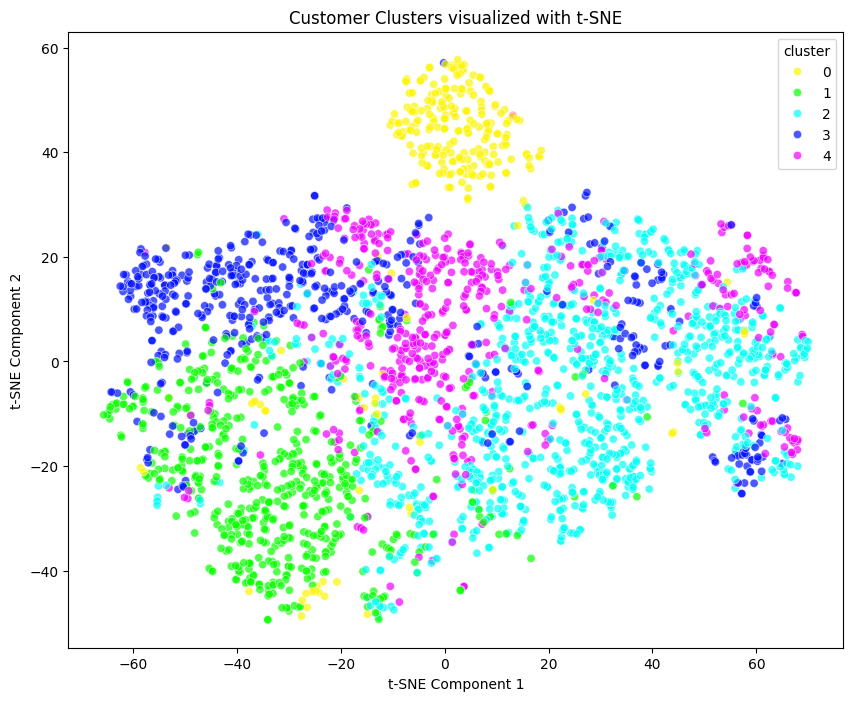

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for t-SNE (exclude the 'cluster' column as it's the target for visualization)
features_for_tsne = subscribers_log_preprocessed_df.drop('cluster', axis=1)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=seed, perplexity=30, max_iter=1000, learning_rate='auto')
tsne_results = tsne.fit_transform(features_for_tsne)

# Create a DataFrame for the t-SNE results
tsne_df = pd.DataFrame(data=tsne_results, columns=['tsne_1', 'tsne_2'])
tsne_df['cluster'] = subscribers_log_preprocessed_df['cluster']

# Plot the t-SNE results
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='tsne_1',
    y='tsne_2',
    hue='cluster',
    palette=sns.color_palette('hsv', optimal_k_new),
    data=tsne_df,
    legend='full',
    alpha=0.7
)
plt.title('Customer Clusters visualized with t-SNE')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(False)
plt.show()

# Conclusion

The subscribers (customers who accepted the product offer) were segmented into 5 different clusters.

**Cluster 1**
*   **Demographics:** Youngest (age: 33.15 years).
*   **Financials:** Moderate balance (751.23)
*   **Campaign Interaction:** Shortest average call duration (285.27 seconds), low campaign contact count (1.56). Contact day is around 18.68. Contact month is April.
*   **Key Traits:** Predominantly single, management roles, tertiary education, cellular contact.

**Cluster 2**
*   **Demographics:** Oldest (age: 55.88 years).
*   **Financials:** Moderate balance (777.95).
*   **Campaign Interaction:** Moderate call duration (562.22 seconds), low campaign contact count (1.67). Contact day is around 13.65. Contact month is April.
*   **Key Traits:** Predominantly retired, married, secondary education, cellular contact.

**Cluster 3**
*   **Demographics:** Middle-aged (age: 41.22 years).
*   **Financials:** Lower balance (631.58).
*   **Campaign Interaction:** Long average call duration (849.82 seconds), highest campaign contact count (5.56). Contact day is around 18.22. Contact month is July.
*   **Key Traits:** Predominantly married, management roles, secondary education, cellular contact.

**Cluster 4**
*   **Demographics:** Young (age: 35.14 years).
*   **Financials:** Lowest average balance (379.88). Most likely to have housing loans.
*   **Campaign Interaction:** Longest average call duration (888.06 seconds), low campaign contact count (1.69). Contact day is around 14.12. Contact month is May.
*   **Key Traits:** Predominantly single, blue-collar workers, secondary education, cellular contact.

**Cluster 5**
*   **Demographics:** Middle-aged (age: 39.09 years).
*   **Financials:** Average balance of 0.00.
*   **Campaign Interaction:** Moderate call duration (682.15 seconds), moderate campaign contact count (2.57). Contact day is around 15.82. Contact month is May.
*   **Key Traits:** Predominantly married, management roles, secondary education, cellular contact.